## Quicksort versione Las Vegas e Monte Carlo - Implementazione e Analisi
L'Algoritmo $\text{Quicksort(S)}$ affronta il classico problema dell'**ordinamento di una sequenza** $S$ di $n$ **numeri**. Le sue **prestazioni** dipendono dall'**ordinamento iniziale** di $S$; nel **caso peggiore**, nel quale si verificano partizionamenti della sequenza sfavorevoli, l'algoritmo **deterministico** ha una complessita' temporale $O(n^2)$. Di seguito vengono proposte due versioni **randomizzate** dell'algoritmo che, con piu' o meno successo, tentano di allontanarsi dal **caso peggiore** e ottengono un numero atteso di confronti pari a $O(nlogn)$.

Il **determinismo** del primo algoritmo si trova nella _scelta esplicita_ di quale elemento considerare come _pivot_, ossia, ad ogni iterazione dell'algoritmo, quale elemento $p$ usiamo come base delle _partizioni_ $S_<, p, S_{\geq}$. Un esercizio che abbiamo visto a lezione e' stato quello di creare la **sequenza peggiore** per una determinata posizione del _pivot_, infatti proprio per la _scelta esplicita_ di quest'ultima e' facile capire come generarla. Ad esempio per la versione **deterministica** di $\text{Quicksort(S)}$ che sceglie come _pivot_ l'elemento _mediano_ e' sufficiente scrivere gli $n$ numeri inserendo nella posizione _mediana_ il numero piu' _piccolo_ (o piu' grande) della sequenza ancora da ordinare.


Ora passiamo al codice, inizio impostando l'ambiente e definendo la sequenza $S$ da analizzare, con $|S| = 10^4$

In [1]:
# Imports
import IPython
import warnings

import random
import math

import matplotlib.pyplot as plt

PATH = "../data/"
N = int(1e4) # 10^4 int

In [2]:
# returns a list of n random int between 0 and 100
def sequence_generator(n):
    s = []
    for i in range(n):
        s.append(random.randint(0, 100))
    return s

# helper swap function
def swap(s, a, b):
    tmp = s[b]
    s[b] = s[a]
    s[a] = tmp
    
s = sequence_generator(N) # random sequence of int

### Las Vegas Quicksort:
Procediamo ora a definire $\text{LVQuicksort(S)}$, prima versione **randomizzata** derivata dall'omonimo **deterministico** che, al posto di effettuare una _scelta irrevocabile esplicita_ del _pivot_, ad ogni chiamata lo campiona con _probabilita' uniforme_ su tutta la sequenza ancora da ordinare. \
L'algoritmo presentato e' considerato di tipo **Las Vegas** in quanto _fornisce sempre l'output corretto anche se, sullo stesso input e' eseguito in istanti diversi_ $t_1, t_2| t_1 \neq t_2$. Ad ogni chiamata l'algoritmo si comportera' esattamente come la versione deterministica e percio' nel **caso peggiore** costera' sempre $O(n^2)$. Per stimare il numero atteso di confronti $X$ nel caso migliore invece, considerate delle variabili indicatrici $I(i,j)$ che indicheranno se $i,j$ vengono confrontati, equivale a calcolare il valore atteso $\mathbb{E}[X] = \mathbb{E}[\sum_{i=1}^{n-1} \sum_{j=i+1}^{n} I(i,j)]$ che, per la _proprieta' della linearita' del valore atteso_, se $p_{ij}(1)$ e' la probabilita' che $i$ e $j$ _siano confrontati_ il **valore atteso del numero di confronti** $X$ diventa $\mathbb{E}[X] = =\sum_{i=1}^{n-1} \sum_{j=i+1}^{n} p_{ij}(1)$. Si hanno soli due casi favorevoli di confrontare $i$ e $j$, $I(i,j)$ e $I(j,i)$, dunque $p_{ij} = \frac{2}{j-1+1}$. Seguendo le note, per $n$, numero di elementi della sequenza, **grande** il **valore atteso del numero di confronti** e' approssimabile a $\mathbb{E}[X] = O(nlogn)$.

Ricapitolando, $\text{LVQuicksort(S)}$, come nel caso **deterministico**, avra' complessita $T_\text{best} = O(nlogn)$ e $T_\text{worst} = O(n^2)$. Il vantaggio di quest'algoritmo deriva dalla scelta **randomica** del _pivot_ e dell'impossibilita' di creare sequenze pessime prevedibili. \
Propongo un'implementazione dell'algoritmo $\text{LVQuicksort(s)}$ basato su quello classico ${\footnotesize{\text{(Recuperato da un laboratorio di ASD)}}}$.

\vspace{8cm}

In [ ]:
# Las Vegas Quicksort
def r_quick_sort(s, start, end, x):
    if start < end:
        pivot = random.randint(start, end) # random index
        swap(s, start, pivot) # the pivot is now a the start of the partition
        pivot = start
        # partition
        i = start+1 
        j=i
        while j <= end:
            x[0] += 1 # i need a way to store the number of comparisons, x[0] = counter, x[1] = limit
            if x[0] >= x[1]: return False # MCQuicksort(S, k), if count >= 2u -> interrupt
            if s[j] < s[pivot]:
                swap(s, i, j)
                i+=1
            j+=1
        swap(s, pivot, i-1)
        pivot = i-1
        # recursive calls
        if pivot > start: 
            if not r_quick_sort(s, start, pivot-1, x): return False
        if pivot < end: 
            if not r_quick_sort(s, pivot+1, end, x): return False
    return True
    
def lv_quicksort(s):
    x = [0, float('inf')] # classic LVQuicksort(S) doesnt have a limit
    if len(s) <= 1:
        return x[0] # number of comparisons
    else:
        r_quick_sort(s, 0, len(s) - 1, x)
        return x[0]

L'implementazione presentata ritorna il **numero totale di confronti effettuati** per ordinare la sequenza $s$ grazie ad un banale contatore. \
L'algoritmo $\text{LVQuicksort(S)}$, come sopra scritto, ha la stessa complessita' della versione **deterministica**, nel caso peggiore avra' quindi un costo di $O(n^2)$, in seguito sara' presentato un metodo, sfruttando la _teoria della probabilita'_, di minimizzare la frequenza del caso $T_\text{worst}$.

\vspace{4cm}

### Monte Carlo Quicksort:
Abbiamo detto che scelte casuali del pivot possono, con bassa probabilita', richiedere $O(n^2)$ confronti. \
Definiamo quindi $\text{MCQuicksort(S, k)}$, algoritmo di tipo **Monte Carlo** che non fa altro che eseguire $k$ volte $\text{LVQuicksort(S)}$ (con qualche accortezza) per ottenere una complessita', ossia il **numero di confronti**, nel caso peggiore $T_\text{worst} = O(nlogn)$.
Essendo pero' un algoritmo di tipo **Monte Carlo**, $\text{MCQuicksort(S, k)}$ potrebbe fallire e non ordinare la sequenza $S$ (il perche' sara' chiarito in seguito). Cio' puo' avvenire con una probabilita' che, scelto un $k$ opportuno, puo' esser resa _infinitesimamente_ piccola.

Ricordando la _disuguaglianza di Markow_: 

$\mathbb{P}(X\geq a)\leq\frac{\mathbb{E}[X]}{a}$, $\footnotesize{\mathbb{E}[X] ~ \text{Valore atteso di una variabile casuale } X\geq 0, \forall a}$ \
Per $a = 2\mathbb{E}[X]$ la disuguaglianza diventa $\mathbb{P}(X\geq 2\mathbb{E}[X])\leq\frac{\mathbb{E}[X]}{2\mathbb{E}[X]} = \mathbb{P}(X\geq 2\mathbb{E}[X])\leq\frac{1}{2}$.

Questa disuguaglianza e' alla base del secondo algoritmo infatti, se $X$ e' la variabile casuale che all'i-esima iterazione di $\text{LVQuicksort(S)}$ ordina la sequenza $S$ in $x_i$ confronti e $k > 0 \in \real$ avremo:

In [ ]:
def mc_quicksort(s, k):
    n = len(s)
    u = n * math.log2(n) # estimated expected value of the number of comparisons necessary to order s, E[X] = nlog(n)
    limit = 2*u
    
    for i in range(k):
        s_copy = list(s)
        x = [0, limit]
        
        if not r_quick_sort(s_copy, 0, n-1, x): # if x > 2(nlog(n)) -> discard iteration
            continue
        else:
            return s_copy

Come annunciato poco fa, essendo un algoritmo di tipologia **Monte Carlo**, $\text{MCQuicksort(S, k)}$ potrebbe fallire e non ordinare la sequenza $S$, infatti nel caso in cui tutte le $k$ iterazioni ordinassero la sequenza $S$ in un numero di confronti superiore a $2\hat\mu$, allora la procedura di ordinamento fallisce. Nel caso peggiore $\text{MCQuicksort(S, k)}$ ordina la sequenza nell'**ultima iterazione** con un costo che non e' superiore a $2k\hat\mu\approx2k\mathbb{E}[X]$ e quindi sempre in $O(nlogn)$ confronti. Tutto sta nello scegliere un $k$ opportuno per rendere trascurabile la probabilita' di _insuccesso_ dell'algoritmo.

Procediamo adesso a **testare** l'algoritmo **Las Vegas** e creiamo un _istorgramma_ delle frequenze dei numeri di confronti effettuati in $i$ iterazioni di $\text{LVQuicksort(S)}$.

\vspace{2cm}


Empirical Average of comparisons: 578083.675


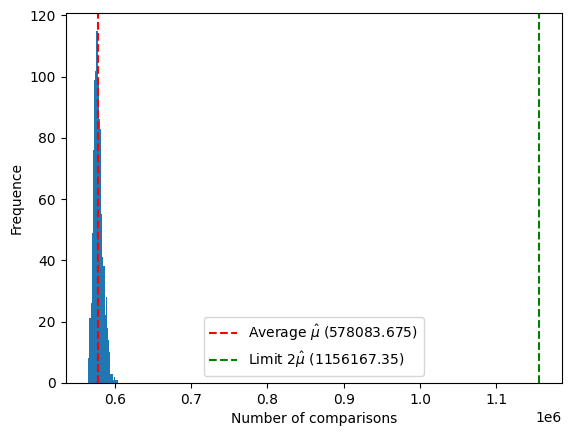

In [4]:
k = int(1e3) # 10^3 run
def iter_lvqs(s, k):
    x = []
    for i in range(k):
        s_copy = list(s)
        x.append(lv_quicksort(s_copy))
    return x
x = iter_lvqs(s, k)
u = sum(x) / len(x)
print(f"\nEmpirical Average of comparisons: {u}")
limit = 2*u
plt.hist(x, bins='auto')
plt.axvline(u, color ='r', linestyle='dashed', label=rf'Average $\hat{{\mu}}$ ({u})')
plt.axvline(limit, color ='g', linestyle='dashed', label=rf'Limit $2\hat{{\mu}}$ ({limit})')
plt.xlabel('Number of comparisons')
plt.ylabel('Frequence')
plt.legend()
plt.show()

dall'_istogramma_ calcolato possiamo dedurre come in realta', **empiricamente**, nessuna delle $k$ iterazioni raggiunge il limite ${2\hat\mu = 2\mathbb{E}[X]}$, per questo motivo possiamo definire la _disuguaglianza di Markow_ pessimista. \
Consideriamo ora $k = 10^5$ iterazioni, supponiamo che tali siano sufficienti ad approssimare la $\text{pmf}$ vera, proviamo quindi a sostituire $\mathbb{E}[X]$ con $\hat\mu$, ponendo $\epsilon = 10^{-5}$, e verifichiamo se $\mathbb{P}(X\geq2\hat\mu)\leq\epsilon$ sia molto piu' precisa di $\mathbb{P}(X\geq 2\mathbb{E}[X])\leq\frac{1}{2}$ o meno.


Empirical Average of comparisons: 578509.37855


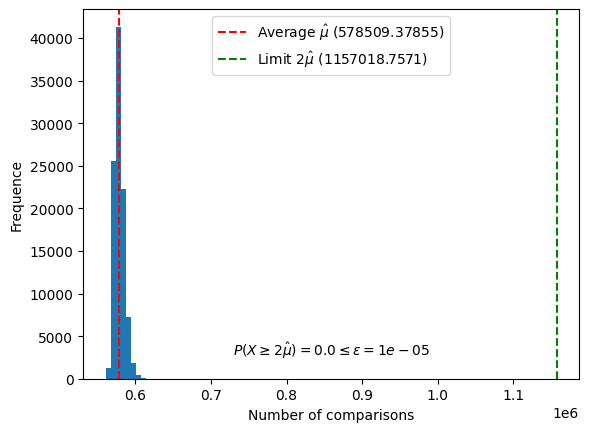

In [14]:
k = int(1e5) # 10^5 run
def iter_lvqs(s, k):
    x = []
    for i in range(k):
        s_copy = list(s)
        x.append(lv_quicksort(s_copy))
        # print(f"\nIteration {i}")
    return x
x = iter_lvqs(s, k)

u = sum(x) / len(x) # E[X] = u
print(f"\nEmpirical Average of comparisons: {u}")
limit = 2*u

epsilon = 1e-5
limit_cases = 0

for i in x:
    if i >= limit:
        limit_cases += 1
p = limit_cases / len(x) # P(X >= 2u)

plt.hist(x)
plt.axvline(u, color ='r', linestyle='dashed', label=rf'Average $\hat{{\mu}}$ ({u})')
plt.axvline(limit, color ='g', linestyle='dashed', label=rf'Limit $2\hat{{\mu}}$ ({limit})')

text = rf'$P(X\geq 2\hat{{\mu}})={p}\leq\epsilon={epsilon}$'
plt.text(0.5, 0.05, text, 
         horizontalalignment='center', 
         verticalalignment='bottom', 
         transform=plt.gca().transAxes)
plt.xlabel('Number of comparisons')
plt.ylabel('Frequence')
plt.legend()
plt.show()

L'algoritmo da me proposto ha impiegato circa 135 minuti per eseguirsi, incuriosito da cio' tento di sviluppare una alternativa in C++ con la speranza di ottenere un tempo di esecuzione piu' ragionevole. Inizio trasferendo la sequenza $S$ su un file di testo.

In [17]:
def outfile (file_name, s):
    with open(PATH + file_name +".txt", 'w') as f:
        for i in s:
            f.write(f"{i}\n")
outfile("out", s)

\vspace{5cm}

``` cpp
std:: random_device rd; // random number generator better than rand() 
std::mt19937 gen(rd());
// Las Vegas Quicksort
void r_quick_sort(std::vector<size_t>& s, size_t start, size_t end, size_t& count) {
    if (start < end) {
        std::uniform_int_distribution<> d(start, end);

        size_t pivot = d(gen); // random index
        swap(s, start, pivot);
        pivot = start;

        size_t i = start + 1;
        size_t j = i;

        while (j <= end) {
            count++;
            if (s.at(j) < s.at(pivot)) {
                swap(s, i, j);
                i++;
            }
            j++;
        }
        swap(s, pivot, i-1);
        pivot = i-1;
        if (pivot > start) {r_quick_sort(s, start, pivot - 1, count);}
        if (pivot < end) {r_quick_sort(s, pivot + 1, end, count);}
    }
}
size_t lv_quicksort(std::vector<size_t>& s) {
    size_t count = 0;
    if (s.size() <=1) {return count;}
    r_quick_sort(s, 0, s.size() - 1, count);
    return count;
}
// returns number of comparisons of LVQuicksort(s) K iterations
const size_t K = 100000;
std::vector<size_t> iter_lvqs(std::vector<size_t>& s, const size_t K) {
    std::vector<size_t> x;
    std::cout << "Starting Algorithm for " << K << " iterations\n";
    for (size_t i = 0; i < K; i++) {
        std::vector<size_t> s_copy = s;
        x.push_back(lv_quicksort(s_copy));
        std::cout << "Iteration " << i << "\n";
    }
    std::cout << "Algorithm finished\n";
    return x;
}
```
L'algoritmo viene eseguito in soli 9 minuti!

Ora recupero la lista del numero di confronti effettuati per ciascuna delle $k=10^5$ iterazioni e produco l'istogramma.


Empirical Average of comparisons: 578515.48136


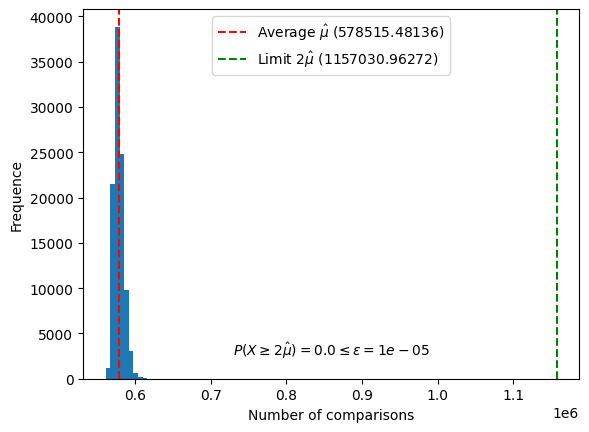

In [18]:
def infile (file_name):
    with open(PATH + file_name +".txt", 'r') as f:
        x = [int(line) for line in f]
    return x
x = infile("in")

u = sum(x) / len(x) # E[X] = u
print(f"\nEmpirical Average of comparisons: {u}")
limit = 2*u

epsilon = 1e-5
limit_cases = 0

for i in x:
    if i >= limit:
        limit_cases += 1
p = limit_cases / len(x) # P(X >= 2u)

plt.hist(x)
plt.axvline(u, color ='r', linestyle='dashed', label=rf'Average $\hat{{\mu}}$ ({u})')
plt.axvline(limit, color ='g', linestyle='dashed', label=rf'Limit $2\hat{{\mu}}$ ({limit})')

text = rf'$P(X\geq 2\hat{{\mu}})={p}\leq\epsilon={epsilon}$'
plt.text(0.5, 0.05, text, 
         horizontalalignment='center', 
         verticalalignment='bottom', 
         transform=plt.gca().transAxes)
plt.xlabel('Number of comparisons')
plt.ylabel('Frequence')
plt.legend()
plt.show()

Poiche' $\mathbb{P}(X\geq 2\hat\mu) = 0 \leq\epsilon=10^-5$ possiamo affermare che la nuova disuguaglianza e' di molto piu' precisa (di quattro ordini di grandezza) della precedente. \
Ora calcoliamo, utilizzando la nuova disuguaglianza appena scoperta, la probabilita' con cui $\text{MCQuicksort(S, k)}$ ordina la sequenza $S$.

 - Secondo la disuguaglianza di Markov: $\mathbb{P}(X\geq 2\mathbb{E}[X])\leq\frac{1}{2}$, si ha una probabilita' che tutti i $k$ tentativi falliscano pari a $\frac{1}{2^k}$, in questo caso, considerato $k=3$, $\mathbb{P}_\text{failure} = \frac{1}{8}$.
 - Utilizzando invece $\mathbb{P}(X\geq 2\hat\mu) \leq \epsilon$,  $\mathbb{P}_\text{failure} \leq 10^-5$ quindi, su $k=3$ tentativi, avremo $\mathbb{P}_\text{failure} \leq \epsilon^3 = 10^{-15}$.

Possiamo dunque notare come la probabilita' di fallimento sia drasticamente scesa, garantendo un successo molto piu' probabile.

$\footnotesize{\text{Baldini Filippo - }6393212}$